In [2]:
import requests
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

EDA: Analizando a API e pegando os dados de interesse

In [3]:
pokemons_capturados = []

# vamos criar um loop que pega todos os primeiros 151 pokemons
for i in range(1, 152):

    url = f"https://pokeapi.co/api/v2/pokemon/{i}"
    resposta = requests.get(url)

    #transformando em um dicionario python (json)
    dados_pokemon = resposta.json()

    #pegando as principais informacoes de cada pokemon
    nome = dados_pokemon['name']
    hp = dados_pokemon['stats'][0]['base_stat']
    attack = dados_pokemon['stats'][1]['base_stat']
    defense = dados_pokemon['stats'][2]['base_stat']
    special_attack = dados_pokemon['stats'][3]['base_stat']
    special_defense = dados_pokemon['stats'][4]['base_stat']
    speed = dados_pokemon['stats'][5]['base_stat']

    #pegando os tipos de cada pokemon
    tipo_1 = dados_pokemon['types'][0]['type']['name']

    #verificando se existe um segundo tipo (nem todos tem)
    if len(dados_pokemon['types']) > 1:
        tipo_2 = dados_pokemon['types'][1]['type']['name']
    else:
        tipo_2 = None 
    

    #pegando a descricao de cada pokemon - novo request
    url_especie = dados_pokemon['species']['url']
    resposta_especie = requests.get(url_especie)

    dados_especie = resposta_especie.json()

    #pegando as descricoes em ingles
    descricoes_unicas = set() #pega apenas as unicas, sem textos repetidos
    for entrada in dados_especie['flavor_text_entries']:
        if entrada['language']['name'] == 'en':
            #limpamos o \n e \f (quebras de linhas)
            texto_limpo = entrada['flavor_text'].replace('\n', ' ').replace('\f', ' ')
            descricoes_unicas.add(texto_limpo)

    #juntamos todas as descricoes (de todos os jogos de pokemon) em um unico paragrafo
    descricao_final = " ".join(descricoes_unicas)
    

    #criando um dicionario com as infos necessarias
    poke_dict = {
        'nome': nome,
        'tipo_1': tipo_1,
        'tipo_2': tipo_2,
        'hp': hp,
        'attack': attack,
        'defense': defense,
        'special_attack': special_attack,
        'special_defense': special_defense,
        'speed': speed,
        'dex_entry': descricao_final 
    }

    #adicionando o dicionario em nossa lista
    pokemons_capturados.append(poke_dict)


#criando nosso dataframe
df_pokemon = pd.DataFrame(pokemons_capturados)

        
    


In [4]:
#analisando o dicionario do PokeAPI e entendendo qual o indice de cada atributo

stats_do_pokemon = dados_pokemon['stats']

for i, item in enumerate(stats_do_pokemon):
    nome_stat = item['stat']['name']
    valor_stat = item['base_stat']
    print(f"Índice [{i}]: {nome_stat} = {valor_stat}")

Índice [0]: hp = 100
Índice [1]: attack = 100
Índice [2]: defense = 100
Índice [3]: special-attack = 100
Índice [4]: special-defense = 100
Índice [5]: speed = 100


In [5]:
df_pokemon.head(10)

,nome,tipo_1,tipo_2,hp,attack,defense,special_attack,special_defense,speed,dex_entry
0,bulbasaur,grass,poison,45,49,49,65,65,45,"While it is young, it uses the nutrients that ..."
1,ivysaur,grass,poison,60,62,63,80,80,60,The bulb on its back grows as it absorbs nutri...
2,venusaur,grass,poison,80,82,83,100,100,80,The flower on its back catches the sun's rays....
3,charmander,fire,None,39,52,43,60,50,65,The flame on its tail indicates CHARMANDER’s l...
4,charmeleon,fire,None,58,64,58,80,65,80,CHARMELEON mercilessly destroys its foes using...
5,charizard,fire,flying,78,84,78,109,85,100,It is said that CHARIZARD’s fire burns hotter ...
6,squirtle,water,None,44,48,65,50,64,43,"It shelters itself in its shell, then strikes ..."
7,wartortle,water,None,59,63,80,65,80,58,"Its tail is large and covered with a rich, thi..."
8,blastoise,water,None,79,83,100,85,105,78,The rocket cannons on its shell fire jets of w...
9,caterpie,bug,None,45,30,35,20,20,45,Its feet have suction cups designed to stick t...


KNN: Criando os clusters baseado nos atributos base

In [6]:
#vamos agora clusterizar, vamos criar grupos baseados nos stats de cada pokemon e tentar tirar analises a partir disso

#primeiro, vamos criar um novo df com apenas as colunas de atributos
df_stats = df_pokemon.drop(columns=['nome', 'tipo_1', 'tipo_2', 'dex_entry'])

df_stats.head()

,hp,attack,defense,special_attack,special_defense,speed
0,45,49,49,65,65,45
1,60,62,63,80,80,60
2,80,82,83,100,100,80
3,39,52,43,60,50,65
4,58,64,58,80,65,80


In [7]:
#padronizando os dados

scaler = StandardScaler()

df_stats_scaled = scaler.fit_transform(df_stats)

c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

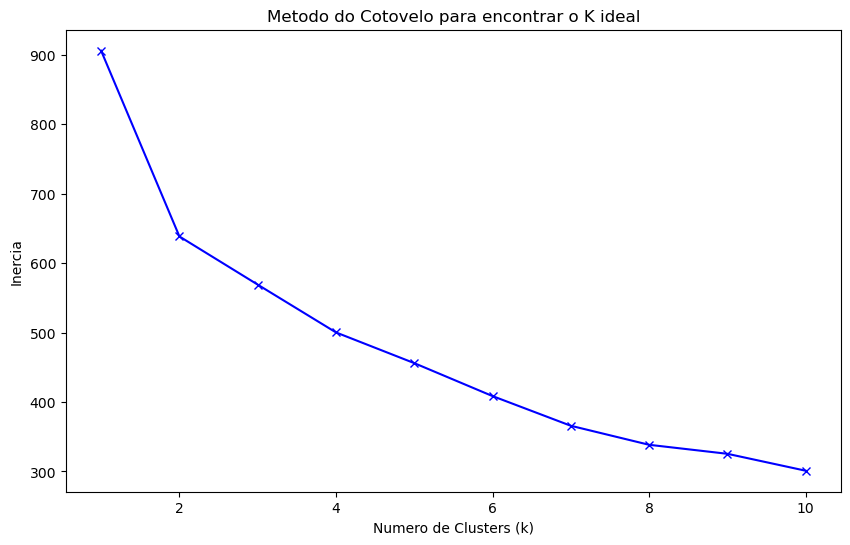

In [8]:
#Usando o metodo do cotovelo (inercia) para descobrirmos quantos clusters usarmos

inercia = []
K = range(1,11)

for k in K:

    kmeans = KMeans(n_clusters=k, random_state=356)
    kmeans.fit(df_stats_scaled)
    inercia.append(kmeans.inertia_)

#plotando o grafico
plt.figure(figsize=(10, 6))
plt.plot(K, inercia, 'bx-')
plt.xlabel('Numero de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Metodo do Cotovelo para encontrar o K ideal')
plt.show()


In [9]:
#analisando o grafico podemos ver que a curva comeca a suavizar entre K=4 e K=5, vamos usar 5 clusters para nosso projeto

kmeans_final = KMeans(n_clusters=5, random_state=356)
kmeans_final.fit(df_stats_scaled)
clusters = kmeans_final.predict(df_stats_scaled)

#adicionando essa nova coluna ao nosso df original
df_pokemon['cluster'] = clusters

df_pokemon.head(10)

c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,nome,tipo_1,tipo_2,hp,attack,defense,special_attack,special_defense,speed,dex_entry,cluster
0,bulbasaur,grass,poison,45,49,49,65,65,45,"While it is young, it uses the nutrients that ...",1
1,ivysaur,grass,poison,60,62,63,80,80,60,The bulb on its back grows as it absorbs nutri...,1
2,venusaur,grass,poison,80,82,83,100,100,80,The flower on its back catches the sun's rays....,2
3,charmander,fire,None,39,52,43,60,50,65,The flame on its tail indicates CHARMANDER’s l...,3
4,charmeleon,fire,None,58,64,58,80,65,80,CHARMELEON mercilessly destroys its foes using...,4
5,charizard,fire,flying,78,84,78,109,85,100,It is said that CHARIZARD’s fire burns hotter ...,4
6,squirtle,water,None,44,48,65,50,64,43,"It shelters itself in its shell, then strikes ...",1
7,wartortle,water,None,59,63,80,65,80,58,"Its tail is large and covered with a rich, thi...",1
8,blastoise,water,None,79,83,100,85,105,78,The rocket cannons on its shell fire jets of w...,2
9,caterpie,bug,None,45,30,35,20,20,45,Its feet have suction cups designed to stick t...,3


In [10]:
#vamos analisar a media de cada atributo por cluster
#isso vai nos dizer qual grupo eh o dos "Rapidos", qual eh o dos "Tanks", etc.
analise_clusters = df_pokemon.groupby('cluster')[['hp', 'attack', 'defense', 'special_attack', 'special_defense', 'speed']].mean()

display(analise_clusters)

,hp,attack,defense,special_attack,special_defense,speed
cluster,,,,,,
0,56.666667,87.857143,112.142857,53.809524,49.047619,51.666667
1,59.419355,62.838710,59.967742,61.000000,64.387097,46.580645
2,104.375000,89.416667,77.375000,82.000000,94.166667,65.000000
3,42.272727,48.454545,42.424242,45.575758,40.393939,64.575758
4,65.809524,82.666667,67.404762,86.785714,80.000000,100.214286


In [11]:
#definindo um dicionario com os nomes e descricao que melhor representam cada cluster
detalhes_clusters = {
    0: {
        "nome": "Muralha Física",
        "desc": "Especialistas em defesa física. Aguentam golpes potentes, mas costumam ser lentos."
    },
    1: {
        "nome": "Equilibrado",
        "desc": "Pokémon equilibrados. Possuem atributos médios e consistentes, sem fraquezas gritantes. Costumam ser pokemons em fases iniciais de evolução."
    },
    2: {
        "nome": "Colosso de Vitalidade",
        "desc": "Os pesos-pesados. Destacam-se pelo HP altíssimo e grande resistência a danos especiais. Possuem os restantes dos atributos médios/altos."
    },
    3: {
        "nome": "Básico",
        "desc": "Estágios primários de evolução. Possuem potencial de crescimento, mas atributos base baixos."
    },
    4: {
        "nome": "Atacante de Elite",
        "desc": "Focados em finalizar batalhas. Combinam alta velocidade com grande poder de ataque e ataque especial."
    }
}

# criando as novas colunas 
df_pokemon['cluster_nome'] = df_pokemon['cluster'].apply(lambda x: detalhes_clusters[x]['nome'])
df_pokemon['cluster_descricao'] = df_pokemon['cluster'].apply(lambda x: detalhes_clusters[x]['desc'])


df_pokemon[['nome', 'cluster_nome', 'cluster_descricao']].head(10)

,nome,cluster_nome,cluster_descricao
0,bulbasaur,Equilibrado,Pokémon equilibrados. Possuem atributos médios...
1,ivysaur,Equilibrado,Pokémon equilibrados. Possuem atributos médios...
2,venusaur,Colosso de Vitalidade,Os pesos-pesados. Destacam-se pelo HP altíssim...
3,charmander,Básico,Estágios primários de evolução. Possuem potenc...
4,charmeleon,Atacante de Elite,Focados em finalizar batalhas. Combinam alta v...
5,charizard,Atacante de Elite,Focados em finalizar batalhas. Combinam alta v...
6,squirtle,Equilibrado,Pokémon equilibrados. Possuem atributos médios...
7,wartortle,Equilibrado,Pokémon equilibrados. Possuem atributos médios...
8,blastoise,Colosso de Vitalidade,Os pesos-pesados. Destacam-se pelo HP altíssim...
9,caterpie,Básico,Estágios primários de evolução. Possuem potenc...


In [12]:
import pickle

#salvando o modelo de K-Means
with open('kmeans_pokemon.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)

#salvando o modelo de padronizacao
with open('scaler_pokemon.pkl', 'wb') as f:
    pickle.dump(scaler, f)

NLP: Trabalhando com as descricoes da Pokedex

In [20]:
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\abc.zip.
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers\av

True

In [26]:
import re
import nltk
from nltk.corpus import stopwords
from nltk import tokenize
import unidecode
from nltk.stem import SnowballStemmer

#removendo stopwords
palavras_irrelevantes = nltk.corpus.stopwords.words('english')

#stopwords sem acento
stopwords_sem_acentos = [unidecode.unidecode(palavra) for palavra in palavras_irrelevantes]

#criando tokens de pontuacao
token_pontuacao = tokenize.WordPunctTokenizer()

#simplificando as palavras
stemmer = SnowballStemmer('english')

#funcao de tratamento, vamos passar linha por linha da nossa 'dex_entry' para ser tratada
def limpeza_texto(texto):

    #removendo os acentos e deixando minusculo
    texto_sem_acento = unidecode.unidecode(texto).lower()

    #quebrando em tokens por pontuacao
    palavras_texto = token_pontuacao.tokenize(texto_sem_acento)

    #removendo as stopwords sem acento e pontuacao
    frase_limpa = [palavra for palavra in palavras_texto if palavra not in stopwords_sem_acentos and palavra.isalpha()]

    #simplificando ao radical as palavras
    frase_simplificada = [stemmer.stem(palavra) for palavra in frase_limpa]

    return ' '.join(frase_simplificada)




In [31]:
#o .apply() envia uma linha por vez para a funcao
df_pokemon['dex_entry_tratada'] = df_pokemon['dex_entry'].apply(limpeza_texto)

df_pokemon[['dex_entry','dex_entry_tratada']].head(10)

,dex_entry,dex_entry_tratada
0,"While it is young, it uses the nutrients that ...",young use nutrient store seed back order grow ...
1,The bulb on its back grows as it absorbs nutri...,bulb back grow absorb nutrient bulb give pleas...
2,The flower on its back catches the sun's rays....,flower back catch sun ray sunlight absorb use ...
3,The flame on its tail indicates CHARMANDER’s l...,flame tail indic charmand life forc healthi fl...
4,CHARMELEON mercilessly destroys its foes using...,charmeleon merciless destroy foe use sharp cla...
5,It is said that CHARIZARD’s fire burns hotter ...,said charizard fire burn hotter experienc hars...
6,"It shelters itself in its shell, then strikes ...",shelter shell strike back spout water everi op...
7,"Its tail is large and covered with a rich, thi...",tail larg cover rich thick fur tail becom incr...
8,The rocket cannons on its shell fire jets of w...,rocket cannon shell fire jet water capabl punc...
9,Its feet have suction cups designed to stick t...,feet suction cup design stick surfac tenaci cl...


In [170]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk import ngrams
from sklearn.model_selection import train_test_split

tfidf = TfidfVectorizer(lowercase=False, max_features=1000, ngram_range=(1,2), min_df=3)
x_tfidf = tfidf.fit_transform(df_pokemon['dex_entry_tratada'])

x_train, x_test, y_train, y_test = train_test_split(x_tfidf, df_pokemon['tipo_1'], random_state=356, stratify=df_pokemon['tipo_1'], test_size=0.2)

In [177]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
acuracia_lr = accuracy_score(y_test, y_pred_lr)
print(f'Acuracia do modelo Regressao Logistica: {acuracia_lr:.2%}')

rf = RandomForestClassifier(n_estimators=200, random_state=356, class_weight='balanced')
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
acuracia_rf = accuracy_score(y_test, y_pred_rf)
print(f'Acuracia do modelo Random Forest: {acuracia_rf:.2%}')

svc = LinearSVC(C=0.1, random_state=356, class_weight='balanced')
svc.fit(x_train, y_train)
y_pred_svc = svc.predict(x_test)
acuracia_svc = accuracy_score(y_test, y_pred_svc)
print(f"Acuracia do modelo LinearSVC: {acuracia_svc:.2%}")

Acuracia do modelo Regressao Logistica: 35.48%
Acuracia do modelo Random Forest: 38.71%
Acuracia do modelo LinearSVC: 61.29%


c:\Users\user\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


In [178]:
#vamos escolher o SVC pois teve uma acuracia maior, entretanto vamos melhorar ainda mais o modelo

#criando uma lista para comparar com os dois tipos reais
indices_teste = y_test.index
acertos_flexiveis = 0

for i, pred in enumerate(y_pred_svc):
    real_1 = df_pokemon.loc[indices_teste[i], 'tipo_1']
    real_2 = df_pokemon.loc[indices_teste[i], 'tipo_2']
    
    #se o chute do modelo for igual a qualquer um dos dois ele acerta
    if pred == real_1 or pred == real_2:
        acertos_flexiveis += 1

acuracia_flexivel = acertos_flexiveis / len(y_test)
print(f"Acuracia Flexivel do SVC: {acuracia_flexivel:.2%}")

Acuracia Flexivel do SVC: 70.97%


In [180]:
#Acurácia no Treino (O que o modelo "decorou")
y_pred_train = svc.predict(x_train)
acuracia_treino = accuracy_score(y_train, y_pred_train)

#Acurácia no Teste (O que o modelo realmente "aprendeu")
acuracia_teste = accuracy_score(y_test, y_pred_svc)

print(f"Acurácia de Treino: {acuracia_treino:.2%}")
print(f"Acurácia de Teste: {acuracia_teste:.2%}")
print(f"Diferença (Gap): {(acuracia_treino - acuracia_teste):.2%}")

Acurácia de Treino: 97.50%
Acurácia de Teste: 61.29%
Diferença (Gap): 36.21%


Em datasets minúsculos (151 linhas), é quase impossível não ter um gap alto se você quiser uma acurácia decente

Salvando os modelos

In [181]:
#salvando os modelos

#salvando o SVC de 1000 features
with open('modelo_pokemon_svc.pkl', 'wb') as f:
    pickle.dump(svc, f)

#salvando o vetorizador de 1000 features 
with open('tfidf_1000.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

#salvando o df final
df_pokemon.to_csv('pokemon_data_final.csv', index=False)